# I'm back
And still confused. Before winter break, I tried to find reasonable parameters for my simulation.
The parameters in question are:

- planet mass (given by observations, more or less)
- semi-major axis (not super important because fargo is dimensionless)
- Sigma slope (we have no idea. From pervious tests, I am pretty sure that the impact on the fargo3d simulations is not that important, since sigma/sigma_0 always looked fairly the same for different values of sigma slope. It is very relevant for radmc3d, however!)
- flaring index (does it even make a difference? Yes, for the observed scattering surface. I am not sure of the impact on fargo simulations. It is very relevant for radmc3d.)
- $\Sigma_0$ (Only relevant for radmc3d)
- pressure scale height at planet radius (relevant for vertical profile; questionable impact on fargo3d simulation)
- $\alpha$ (the big question mark. Possibly estimated by the gap being transparent/not transparent, width and position of dark rings (shadows cast by denser regions?), and presence of spirals/no spirals)

The parameter space is very big, :(

## The goal

Figure out what parameters could give rise to the images we observed.
We need to proceed in two steps:
- Simulate the density distribution with fargo3d. Relevant parameters:
    - $M_p$
    - $\alpha$ (!)
    - Sigma slope (??)
    - Flaring index (?)
    - pressure scale height at some point (?)
- Based on these densities, simulate scattering-light images with radmc3d. Relevant parameters:
    - $\Sigma_0$ (!)
    - (Sigma slope)
    - (Flaring index)
    - (Pressure scale height at some point)

(!) = Super important

(?) = Not sure if it has an impact on farg3d simulation

(??) = Very unsure if it has an impact on fargo3d simulation, maybe edit in later?

## Bottlenecks for simulations
- We can only run one fargo simulation at a time. Duration ~ 30 mins or longer, depending on number of time steps and resolution. (Do we even need a good resolution?)
- We can only simulate one image at a time with radmc3d. Duration ~ 3 mins

## Now
Do I still want to make these images to show to Birnstiel (Kees' colleague) or is this opportunity dead?
Even if it is, is it useful to make these images anyway?
How many images do I want? What combinations? I'm thinking of finding 3 "reasonable" values for all the parameters, defaulting to the middle one for each, and only changing one at a time to a different value. That gives us $2n +1$ images for $n$ parameters.  Currently, we have 6-ish parameters. We know reasonable values for the planet mass, $\alpha$, flaring index (kinda, dicated by thermal equilibrium), pressure scale height at some point (also kinda dicated by thermal equilibrium). We could get a guess for $\Sigma_0$ from the MMSN (at least the correct order of magnitude). Sigma slope for the initial conditions is hard.

Since changing $\Sigma_0$ doesn't require it's own simulation,  that puts us at 11 simulations with fargo3d and 13 with radmc3d.
I suspect we could edit in the pressure scale height in post just like with $\Sigma_0$.


- $M_p$ = 0.0047  +  0.0009  -  0.0006 Solar masses
- $\alpha$ is in between $10^{-2}$ and $10^{-4}$.
- Flaring index should be around 0.25, if incidence angle doesn't depend on r, and if the stellar luminosity is comparable to our sun. See also Armitage p. 42, eq. (2.38). The pressure scale height can be derived from the temperature:
$T_{mid}\propto r^{-1/4}$, $c_s \propto T^{1/2} \propto r^{-1/4}$, $H_{press} = c_s/\Omega_K$, $\Omega_K \propto r^{-3/2}$, $H_p/r \propto r^{1/4}$
- aspect ratio at planet position should be around 0.075 (see `toy_model.ipynb`) if assumptions made for flaring index are correct.
- $\Sigma_0$

The MMSN has $\Sigma(r) = 1.7\cdot 10^3 (r/1AU)^{-3/2} g/cm^2$. So at 57 AU, at least

In [1]:
print("MMSN: Sigma at 57 au:", 1.7e3*(57/1)**(-3/2), "g/cm²")

MMSN: Sigma at 57 au: 3.950359661422061 g/cm²


Maybe we can try one order of magnitude more, and some value in-between.
The question is, is this value still reasonable if sigma slope = 0, as we argue further below?

- Sigma slope
Is -3/2 in the MMSN. If you consider angular momentum transport, *sigma slope = 0* is a good assumption, because that's the steady-state solution far away from the stellar surface. (See p. 72 Armitage)

## What is the luminosity of the star in the WISPIT 2 system? 
## Is the disk being heated actively or passively? (by the star or by accretion?) This could change the temperature profile.

## Scattering surface - rough estimate
We now want to see if we can obtain a scattering surface that matches the observations (at least approximately) with these reasonable values that we have determined.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Note: all recycled from radmc3d.

au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi

# Star parameters
# taken from van capelleveen paper. Not the same as default!
mstar    = 1.0*ms#2.4*ms
rstar    = 1.418*rs#2.4*rs
tstar    = 4400#1e4
pstar    = np.array([0.,0.,0.])


r0       = 57*au    # The radius corresponding to '1' in dimensionless units
r_res = 100
rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
# we don't really need this
#phi_res = 200
#phic = np.linspace(0,2*np.pi, phi_res)

# unclear if this value is correct/makes sense
sigma_0 = 1.7e3 #g/cm²

dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
#sigma_gas_2d   = np.ones([r_res,phi_res])*sigma_0
sigma_gas_1d   = np.ones(r_res)*sigma_0
sigma_dust_1d = sigma_gas_1d*dtg_smalldust

#r_2d,phi_2d = np.meshgrid(rc,phic,indexing='ij')

Text(0, 0.5, '$\\Sigma_{dust}$ [g/cm²]')

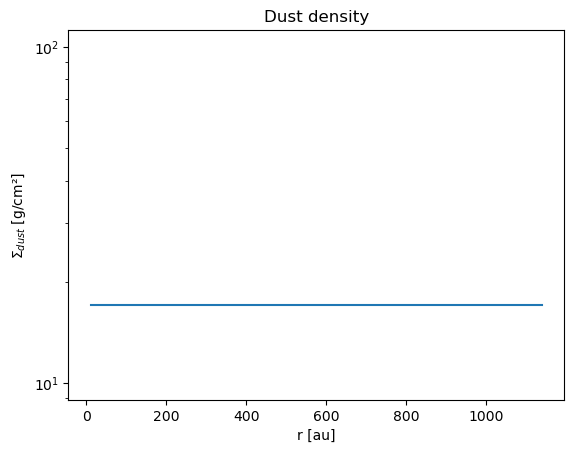

In [4]:

"""
Just a plot to check the density
"""
plt.plot(rc/au, sigma_dust_1d)
plt.yscale("log")
plt.xlabel("r [au]")
plt.title("Dust density")
plt.ylabel("$\\Sigma_{dust}$ [g/cm²]")

In [5]:
#
# Now make a simple analytical disk model roughly along the
# lines of Chiang & Goldreich (1997), but with just a single
# vertical layer and with a constant radiative incidence angle.
#

"""
How are the incidence angle and the flaring index/aspect ratio related?

The incidence angle is given by alpha = h/r -dh/dr (according to armitage's book). So it will depend on r for a flared disk!

Also, we're assuming here that the disk radiates as a black body and is vertially isothermal. (In particular there's no dust
in the way)

What is a reasonable value for flang?
It's not really self-consistent to choose a constant value for it . . .

"""
r_1d=rc
r=rc
flang    = 0.05                        # The assumed constant radiative incidence angle
lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
hp       = cs/omk                      # The pressure scale height
hpr      = hp/rc                        # The dimensionless hp

#
# Compare the results to the AspectRatio and FlaringIndex of
# the FARGO3D setup. Note that we compute them using a simple
# Chiang & Goldreich like model, but this also has a free
# parameter: flang (the incidence angle). Since we keep this
# angle constant, the FlaringIndex should be 0.25, because
# T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
# so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
#
AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
print('If these values are vastly different from those in the FARGO3D .par file,')
print('you should either modify the parameters in the RADMC-3D model, or the parameters')
print('in the FARGO3D model, to make them both mutually self-consistent.')

Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.07183453369090562
  FlaringIndex in RADMC-3D model at R0 = 0.25083982328540594
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


By playing with this i noticed that the flaring index doesn't depend much on the incidence angle. The incidence angle mostly changes the aspect ratio.

In [6]:
omk_1d      = np.sqrt(GG*mstar/r_1d**3)  # The Kepler frequency Omega_K in 1/s
cs_1d = cs  # The isothermal sound speed c_s in cm/s
hp_1d       = cs_1d/omk_1d               # The press scale height H_p = c_s / Omega_K in cm
hpr_1d      = hp_1d/r_1d                 # The aspect ratio H_p / r
vth_1d      = np.sqrt(8/np.pi)*cs_1d     # The thermal velocity of H2 gas particles in cm/s
rho_gas_mid_1d = sigma_gas_1d/(np.sqrt(2*pi)*hp_1d)  # Midplane gas density in g/cm^3


# No idea if this is a good value.
thetaup = 0.1
ntheta   = 32
thetac   = np.linspace(thetaup,0.5e0*np.pi,ntheta)

# Make the 3-D grid
#
qq       = np.meshgrid(rc,thetac,indexing='ij')
rr       = qq[0]
tt       = qq[1]
zr       = np.pi/2.e0 - qq[1]

#
# For later vertical normalization: the Delta z
# (we integrate along theta, i.e. not exactly vertical)
#
#dz       = zr[:,:-1]*rr[:,:-1]-zr[:,1:]*rr[:,1:]

#
# Expand the 2-D gas model to 3-D
#
sigma_gas_3d  = np.zeros_like(rr)
hh_3d         = np.zeros_like(rr)
hhr_3d        = np.zeros_like(rr)
sigma_dust_3d  = np.zeros_like(rr)

for it in range(ntheta):
    sigma_gas_3d[:,it]= sigma_gas_1d[:]
    sigma_dust_3d[:,it] = sigma_dust_1d[:]
    hh_3d[:,it]        = hp_1d[:]
    hhr_3d[:,it]       = hpr_1d[:]
rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

#
# Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
#

rho_dust_3d = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

(100, 32)


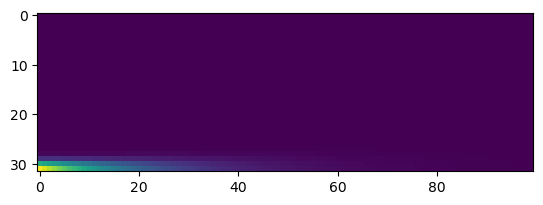

In [7]:
plt.imshow(np.transpose(rho_dust_3d), origin="upper")
print(np.shape(rho_gas_3d))

In [8]:
optical_depth_K = np.zeros_like(rho_dust_3d)
optical_depth_H = np.zeros_like(rho_dust_3d)
kappa_K = 327.86636079024055 # that's kappa_tot_K in cm²/g
kappa_H = 946.506869910016 #g/cm², now for the H-Band
for i in range(len(thetac)):
    # density along line of sight
    dens= 0
    for j in range(len(rc)):
        if j==0 or j==len(rc)-1:
            continue
        # Is this the correct dr???
        dens += rho_dust_3d[j][i]*(rc[j+1]-rc[j-1])*0.5
        optical_depth_K[j][i] = dens*kappa_K
        optical_depth_H[j][i] = dens*kappa_H

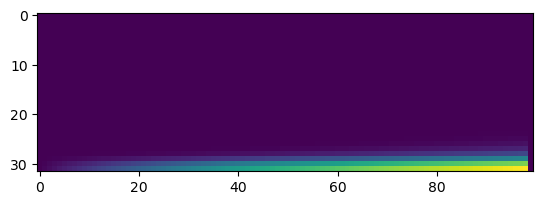

In [9]:
plt.imshow(np.transpose(optical_depth_H))

In [10]:
tau_list = [0.1,1,10]
r_list_H =[]
r_list_K =[]
for t in tau_list:
    r_list_H.append([])
    r_list_K.append([])
    for i in range(len(thetac)):
        r_ = np.interp(t,optical_depth_H[1:-1,i], rc[1:-1])
        r_list_H[-1].append(r_)
        r_ = np.interp(t,optical_depth_K[1:-1,i], rc[1:-1])
        r_list_K[-1].append(r_)
r_list_H = np.array(r_list_H)
r_list_K = np.array(r_list_K)

Text(0.5, 1.0, 'Scattering surface K-band')

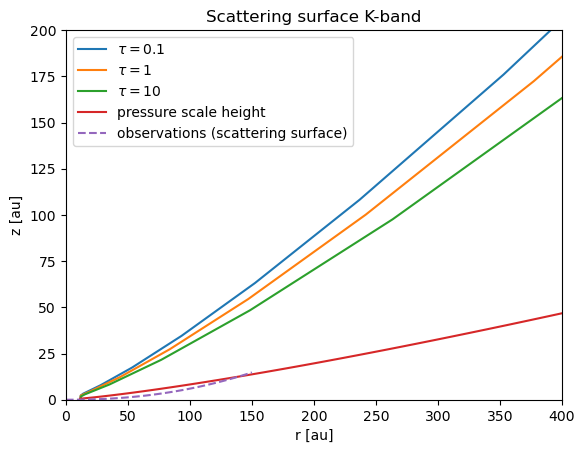

In [11]:
for i in range(len(tau_list)):
    plt.plot(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, label=f"$\\tau= {tau_list[i]}$")

plt.xlabel("r [au]")
plt.ylabel("z [au]")

plt.plot(rc/au, hp/au, label="pressure scale height")

r_ = np.linspace(0,150,100)
plt.plot(r_, r_*0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed")
plt.legend()
#plt.axis("equal")
plt.xlim(0,400)
plt.ylim(0,200)
plt.title("Scattering surface K-band")

Text(0.5, 1.0, 'Scattering surface H-band')

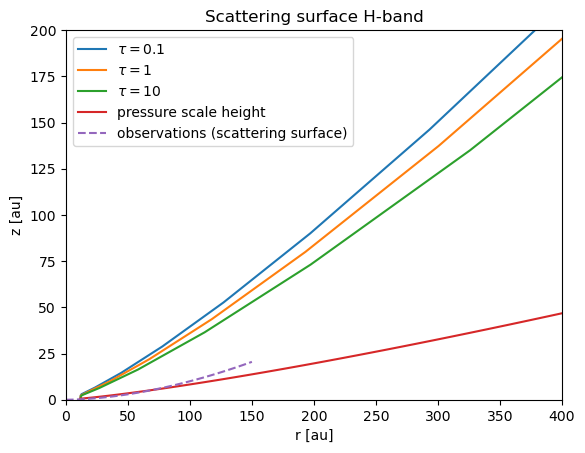

In [12]:
for i in range(len(tau_list)):
    plt.plot(r_list_H[i]/au, np.cos(thetac)*r_list_H[i]/au, label=f"$\\tau= {tau_list[i]}$")

plt.xlabel("r [au]")
plt.ylabel("z [au]")

plt.plot(rc/au, hp/au, label="pressure scale height")

r_ = np.linspace(0,150,100)
plt.plot(r_, r_*0.10*np.power(r_/100, 0.77), label="observations (scattering surface)", linestyle="dashed")
plt.legend()
#plt.axis("equal")
plt.xlim(0,400)
plt.ylim(0,200)
plt.title("Scattering surface H-band")

/scratch/2045982/ipykernel_2368254/744261609.py:17: RuntimeWarning: invalid value encountered in divide
  plt.plot(r_surf/au, dz/dr-z_surf/r_surf)


(0.0, 200.0)

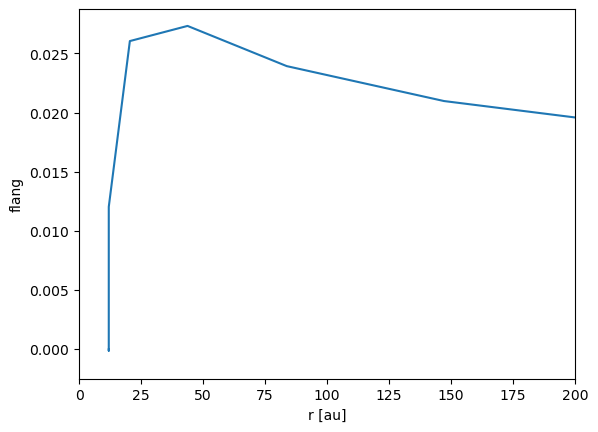

In [13]:
# We try to calculate flang, to see if our model is self-consistent.

r_surf = r_list_K[1]
theta_surf = thetac

z_surf = r_surf*np.cos(theta_surf)

dz = np.zeros_like(z_surf)
dr = np.zeros_like(r_surf)
for i in range(len(z_surf)):
    if i==0 or i==len(z_surf)-1: 
        continue
    dz[i] = 0.5*(z_surf[i-1]+z_surf[i+1])
    dr[i] = 0.5*(r_surf[i-1]+r_surf[i+1])


plt.plot(r_surf/au, dz/dr-z_surf/r_surf)
plt.xlabel("r [au]")
plt.ylabel("flang")
plt.xlim(0,200)

## Now, we try to make it easier to change variables like Sigma_0 etc.

In [14]:
def make_model(sigma_0 = 1.7e3, #g/cm²,
              sigma_slope=0,
              flang    = 0.05                        # The assumed constant radiative incidence angle,
    ):

    print("INPUT:")
    print(f"sigma_0: {sigma_0} g/cm² \nsigma_slope : {sigma_slope}\nflang: {flang}\n------")
    # Note: all recycled from radmc3d.
    
    au  = 1.49598e13     # Astronomical Unit       [cm]
    pc  = 3.08572e18     # Parsec                  [cm]
    ms  = 1.98892e33     # Solar mass              [g]
    ts  = 5.78e3         # Solar temperature       [K]
    ls  = 3.8525e33      # Solar luminosity        [erg/s]
    rs  = 6.96e10        # Solar radius            [cm]
    ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
    kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
    mp  = 1.6726e-24     # Mass of proton          [g]
    GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
    pi  = np.pi          # Pi
    
    # Star parameters
    # taken from van capelleveen paper. Not the same as default!
    mstar    = 1.08*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4
    pstar    = np.array([0.,0.,0.])
    
    
    r0       = 57*au    # The radius corresponding to '1' in dimensionless units
    r_res = 1000
    rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
        
    dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
    #sigma_gas_2d   = np.ones([r_res,phi_res])*sigma_0
    sigma_gas_1d   = np.power(rc/r0,-sigma_slope)*sigma_0
    sigma_dust_1d = sigma_gas_1d*dtg_smalldust

    r_1d=rc
    r=rc
    
    lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
    firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
    tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
    cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
    omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
    hp       = cs/omk                      # The pressure scale height
    hpr      = hp/rc                        # The dimensionless hp
    
    #
    # Compare the results to the AspectRatio and FlaringIndex of
    # the FARGO3D setup. Note that we compute them using a simple
    # Chiang & Goldreich like model, but this also has a free
    # parameter: flang (the incidence angle). Since we keep this
    # angle constant, the FlaringIndex should be 0.25, because
    # T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
    # so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
    #
    AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
    flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
    FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
    print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
    print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
    print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
    print('If these values are vastly different from those in the FARGO3D .par file,')
    print('you should either modify the parameters in the RADMC-3D model, or the parameters')
    print('in the FARGO3D model, to make them both mutually self-consistent.')

    omk_1d      = np.sqrt(GG*mstar/r_1d**3)  # The Kepler frequency Omega_K in 1/s
    cs_1d = cs  # The isothermal sound speed c_s in cm/s
    hp_1d       = cs_1d/omk_1d               # The press scale height H_p = c_s / Omega_K in cm
    hpr_1d      = hp_1d/r_1d                 # The aspect ratio H_p / r
    vth_1d      = np.sqrt(8/np.pi)*cs_1d     # The thermal velocity of H2 gas particles in cm/s
    rho_gas_mid_1d = sigma_gas_1d/(np.sqrt(2*pi)*hp_1d)  # Midplane gas density in g/cm^3
    
    
    # No idea if this is a good value.
    thetaup = 0.1
    ntheta   = 1000
    thetac   = np.linspace(thetaup,0.5e0*np.pi,ntheta)
    
    # Make the 3-D grid
    #
    qq       = np.meshgrid(rc,thetac,indexing='ij')
    rr       = qq[0]
    tt       = qq[1]
    zr       = np.pi/2.e0 - qq[1]
    
    #
    # For later vertical normalization: the Delta z
    # (we integrate along theta, i.e. not exactly vertical)
    #
    #dz       = zr[:,:-1]*rr[:,:-1]-zr[:,1:]*rr[:,1:]
    
    #
    # Expand the 2-D gas model to 3-D
    #
    sigma_gas_3d  = np.zeros_like(rr)
    hh_3d         = np.zeros_like(rr)
    hhr_3d        = np.zeros_like(rr)
    sigma_dust_3d  = np.zeros_like(rr)
    
    for it in range(ntheta):
        sigma_gas_3d[:,it]= sigma_gas_1d[:]
        sigma_dust_3d[:,it] = sigma_dust_1d[:]
        hh_3d[:,it]        = hp_1d[:]
        hhr_3d[:,it]       = hpr_1d[:]
    rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
    
    #
    # Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
    #
    
    rho_dust_3d = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)

    return rho_dust_3d, rc, thetac,hp,flang

In [ ]:

"""for j in range(len(rc)):
            
            if j==0:
                dens += rho_dust_3d[j][i]*(rc[j])
            elif j==len(rc)-1:
                dens += rho_dust_3d[j][i]*(rc[j]-rc[j-1])
            else:
                # Is this the correct dr???
                dens += rho_dust_3d[j][i]*(rc[j+1]-rc[j-1])*0.5
            optical_depth_K[j][i] = dens*kappa_K
            optical_depth_H[j][i] = dens*kappa_H"""

In [50]:
def make_scat(rho_dust_3d, rc, thetac,hp, flang):
    au  = 1.49598e13     # Astronomical Unit       [cm]
    optical_depth_K = np.zeros_like(rho_dust_3d)
    optical_depth_H = np.zeros_like(rho_dust_3d)
    kappa_K = 327.86636079024055 # cm²/g for the K band
    kappa_H = 946.506869910016 #cm²/g, now for the H-Band
    for i in range(len(thetac)):
        # density along line of sight
        dens= 0
        for j in range(len(rc)):
            if j==0:
                dens += rho_dust_3d[j][i]*(rc[j])
            elif j==len(rc)-1:
                dens += rho_dust_3d[j][i]*(rc[j]-rc[j-1])
            else:
                # Is this the correct dr???
                dens += rho_dust_3d[j][i]*(rc[j+1]-rc[j-1])*0.5
            optical_depth_K[j][i] = dens*kappa_K
            optical_depth_H[j][i] = dens*kappa_H
            
    tau_list = [0.1,1,10]
    r_list_H =[]
    r_list_K =[]
    for t in tau_list:
        r_list_H.append([])
        r_list_K.append([])
        for i in range(len(thetac)):
            r_ = np.interp(t,optical_depth_H[1:-1,i], rc[1:-1])
            r_list_H[-1].append(r_)
            r_ = np.interp(t,optical_depth_K[1:-1,i], rc[1:-1])
            r_list_K[-1].append(r_)
    r_list_H = np.array(r_list_H)
    r_list_K = np.array(r_list_K)

    #### Now plot ####
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for i in range(len(tau_list)):
        plt.scatter(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, s=10, marker="x")
        plt.plot(r_list_K[i]/au, np.cos(thetac)*r_list_K[i]/au, label=f"$\\tau= {tau_list[i]}$")
        
    plt.xlabel("r [au]")
    plt.ylabel("z [au]")
    
    plt.plot(rc/au, hp/au, label="pressure scale height")
    
    r_ = np.linspace(0,150,100)
    plt.plot(r_, r_*0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(0,400)
    plt.ylim(0,200)
    plt.title("Scattering surface K-band")

    plt.subplot(1,2,2)

    for i in range(len(tau_list)):
        plt.scatter(r_list_H[i]/au, np.cos(thetac)*r_list_H[i]/au, s=10, marker="x")
        plt.plot(r_list_H[i]/au, np.cos(thetac)*r_list_H[i]/au, label=f"$\\tau= {tau_list[i]}$")
    
    plt.xlabel("r [au]")
    plt.ylabel("z [au]")
    
    plt.plot(rc/au, hp/au, label="pressure scale height")
    
    r_ = np.linspace(0,300,100)
    plt.plot(r_, r_*0.10*np.power(r_/100, 0.77), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(0,400)
    plt.ylim(0,200)
    plt.title("Scattering surface H-band")

    plt.show()



    ###########
#### Now plot ####
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    for i in range(len(tau_list)):
        plt.scatter(r_list_K[i]/au, np.cos(thetac), s=10, marker="x")
        plt.plot(r_list_K[i]/au, np.cos(thetac), label=f"$\\tau= {tau_list[i]}$")
        
    plt.xlabel("r [au]")
    plt.ylabel("z&r [au]")
    
    plt.plot(rc/au, hp/rc, label="pressure scale height")
    
    r_ = np.linspace(0,150,100)
    plt.plot(r_, 0.06*np.power(r_/100, 1.22), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(4,400)
    #plt.ylim(0,1)
    plt.xscale("log")
    plt.title("Scattering surface K-band")

    plt.subplot(1,2,2)

    for i in range(len(tau_list)):
        plt.scatter(r_list_H[i]/au, np.cos(thetac), s=10, marker="x")
        plt.plot(r_list_H[i]/au, np.cos(thetac), label=f"$\\tau= {tau_list[i]}$")
    
    plt.xlabel("r [au]")
    plt.ylabel("z&r [au]")
    
    plt.plot(rc/au, hp/rc, label="pressure scale height")

    r_ = np.linspace(0,300,100)
    plt.plot(r_, 0.10*np.power(r_/100, 0.77), label="observations (scattering surface)", linestyle="dashed")
    plt.legend()
    #plt.axis("equal")
    plt.xlim(4,400)
    plt.xscale("log")
    #plt.ylim(0,1)
    plt.title("Scattering surface H-band")

    plt.show()
    
    #### Plot to compare flang

    # We try to calculate flang, to see if our model is self-consistent.

    r_surf = r_list_H[1]
    theta_surf = thetac
    
    z_surf = r_surf*np.cos(theta_surf)
    
    dz = np.zeros_like(z_surf)
    dr = np.zeros_like(r_surf)
    for i in range(len(z_surf)):
        if i==0 or i==len(z_surf)-1: 
            continue
        dz[i] = 0.5*(z_surf[i-1]+z_surf[i+1])
        dr[i] = 0.5*(r_surf[i-1]+r_surf[i+1])
    
    
    plt.plot(r_surf/au, dz/dr-z_surf/r_surf, label="from scattering surface")
    plt.plot(r_surf/au, np.ones_like(r_surf)*flang, label="input")
    plt.xlabel("r [au]")
    plt.ylabel("flang")
    plt.legend()
    #plt.xlim(0,200)

    r_surf = r_surf[1:-1]
    z_surf = z_surf[1:-1]
    dr = dr[1:-1]
    dz = dz[1:-1]
    
    flang_like = []
    for r_ in rc:
        flang_like.append(np.interp(r_, r_surf,  dz/dr-z_surf/r_surf))

    return flang_like

INPUT:
sigma_0: 0.3 g/cm² 
sigma_slope : -1
flang: 0.1
------
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.0753826193948975
  FlaringIndex in RADMC-3D model at R0 = 0.24968493690645638
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


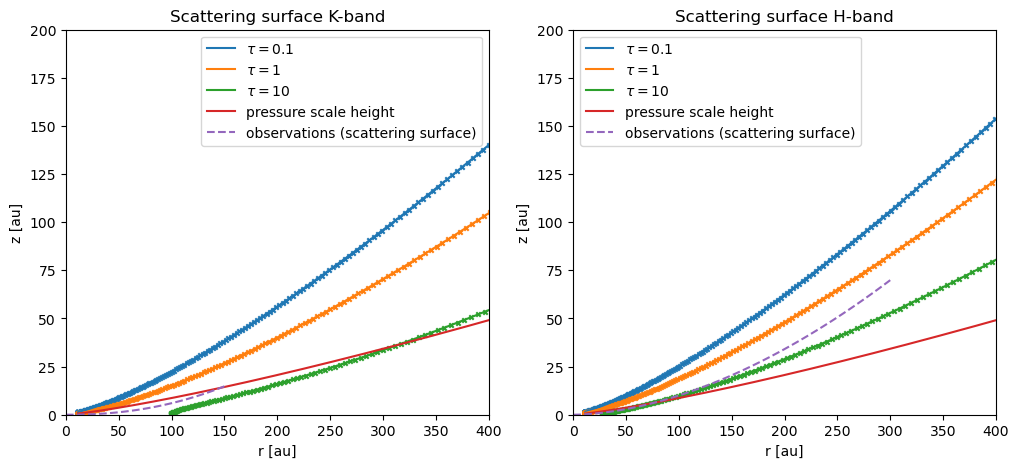

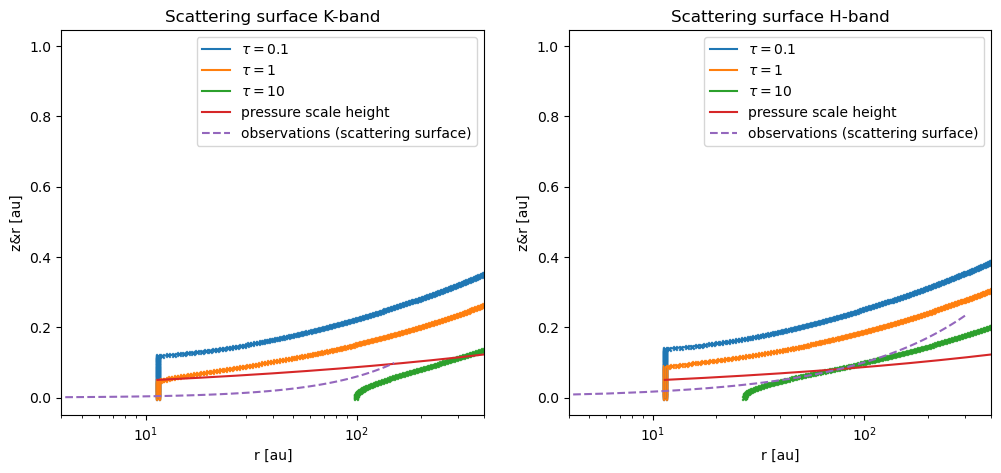

/scratch/2045982/ipykernel_2368254/4272203574.py:140: RuntimeWarning: invalid value encountered in divide
  plt.plot(r_surf/au, dz/dr-z_surf/r_surf, label="from scattering surface")


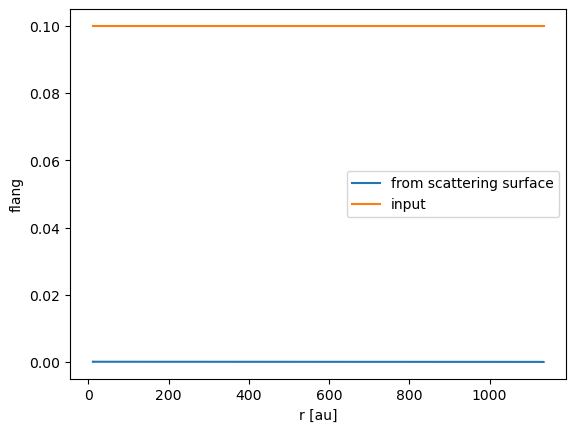

In [59]:
rho_dust_3d, rc, thetac,hp, flang = make_model(sigma_0 = 0.3, #g/cm²,
                                               sigma_slope=-1,flang    = 0.1 )
flang_like = make_scat(rho_dust_3d, rc, thetac,hp, flang)

This is clearly not working well. Lowering sigma_0 is like scaling the scattering surfaces with a factor. Changing sigma slope has barely any effect at all. Maybe the incidence angle can be changed??
The slope of the observations can't really be matched with this model.

In [26]:
mstar    = 1.08*ms#2.4*ms
rstar    = 1.418*rs#2.4*rs
tstar    = 4400
lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity

lsun = 4*pi*rs**2*ss*6000**4

print(lstar/lsun)

0.5815113103012346


We abandon all physicality and try to force the correct temperature profile - by just setting the flaring index and the aspect ratio directly.

In [74]:
def make_model_no_flang(sigma_0 = 1.7e3, #g/cm²,
              sigma_slope=0,
            hp0 = 0.075, # aspect ratio at planet
            flaring_index = 0.25,
    ):

    print("INPUT:")
    print(f"sigma_0: {sigma_0} g/cm² \nsigma_slope : {sigma_slope}\nhp0 : {hp0}\nflaring_index : {flaring_index}\n------")
    # Note: all recycled from radmc3d.
    
    au  = 1.49598e13     # Astronomical Unit       [cm]
    pc  = 3.08572e18     # Parsec                  [cm]
    ms  = 1.98892e33     # Solar mass              [g]
    ts  = 5.78e3         # Solar temperature       [K]
    ls  = 3.8525e33      # Solar luminosity        [erg/s]
    rs  = 6.96e10        # Solar radius            [cm]
    ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
    kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
    mp  = 1.6726e-24     # Mass of proton          [g]
    GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
    pi  = np.pi          # Pi
    
    # Star parameters
    # taken from van capelleveen paper. Not the same as default!
    mstar    = 1.08*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4
    pstar    = np.array([0.,0.,0.])
    
    
    r0       = 57*au    # The radius corresponding to '1' in dimensionless units
    r_res = 1000
    rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
        
    dtg_smalldust  = 1e-2        # Dust to gas ratio for small dust following the gas
    #sigma_gas_2d   = np.ones([r_res,phi_res])*sigma_0
    sigma_gas_1d   = np.power(rc/r0,-sigma_slope)*sigma_0
    sigma_dust_1d = sigma_gas_1d*dtg_smalldust

    r_1d=rc
    r=rc
    """
    lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
    firr     = flang*lstar/(4*pi*r**2)     # Irradiative flux
    tmid     = (firr/ss)**0.25             # Estimate of midplane temperature
    cs       = np.sqrt(kk*tmid/(2.3*mp))   # Isothermal sound speed at midplane
    omk      = np.sqrt(GG*mstar/r**3)      # The Kepler angular frequency
    """
    hp       = rc*hp0*np.power(rc/r0, flaring_index)                      # The pressure scale height
    hpr      = hp/rc                        # The dimensionless hp
    
    #
    # Compare the results to the AspectRatio and FlaringIndex of
    # the FARGO3D setup. Note that we compute them using a simple
    # Chiang & Goldreich like model, but this also has a free
    # parameter: flang (the incidence angle). Since we keep this
    # angle constant, the FlaringIndex should be 0.25, because
    # T ~ r**(-1) --> c_s ~ r**(-0.5), and Omega_K ~ r**(-1.5),
    # so H_p/r = c_s / (Omega_K * r) ~ r**(0.25).
    #
    AspectRatio  = np.interp(r0,r,hpr)     # The H_p/r at r=r0
    flidx        = ( np.log(hpr) - np.log(AspectRatio) ) / ( np.log(r) - np.log(r0) )
    FlaringIndex = np.interp(r0,r,flidx)   # The Flidx at r=r0
    print('Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:')
    print('  AspectRatio in RADMC-3D model at R0  = {}'.format(AspectRatio))
    print('  FlaringIndex in RADMC-3D model at R0 = {}'.format(FlaringIndex))
    print('If these values are vastly different from those in the FARGO3D .par file,')
    print('you should either modify the parameters in the RADMC-3D model, or the parameters')
    print('in the FARGO3D model, to make them both mutually self-consistent.')

    #omk_1d      = np.sqrt(GG*mstar/r_1d**3)  # The Kepler frequency Omega_K in 1/s
    #cs_1d = cs  # The isothermal sound speed c_s in cm/s
    hp_1d       = hp              # The press scale height H_p = c_s / Omega_K in cm
    hpr_1d      = hp_1d/r_1d                 # The aspect ratio H_p / r
    #vth_1d      = np.sqrt(8/np.pi)*cs_1d     # The thermal velocity of H2 gas particles in cm/s
    rho_gas_mid_1d = sigma_gas_1d/(np.sqrt(2*pi)*hp_1d)  # Midplane gas density in g/cm^3
    
    
    # No idea if this is a good value.
    thetaup = 0.1
    ntheta   = 1000
    thetac   = np.linspace(thetaup,0.5e0*np.pi,ntheta)
    
    # Make the 3-D grid
    #
    qq       = np.meshgrid(rc,thetac,indexing='ij')
    rr       = qq[0]
    # Star parameters
    # taken from van capelleveen paper. Not the same as default!
    mstar    = 1.0*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4    tt       = qq[1]
    zr       = np.pi/2.e0 - qq[1]
    
    #
    # For later vertical normalization: the Delta z
    # (we integrate along theta, i.e. not exactly vertical)
    #
    #dz       = zr[:,:-1]*rr[:,:-1]-zr[:,1:]*rr[:,1:]
    
    #
    # Expand the 2-D gas model to 3-D
    #
    sigma_gas_3d  = np.zeros_like(rr)
    hh_3d         = np.zeros_like(rr)
    hhr_3d        = np.zeros_like(rr)
    sigma_dust_3d  = np.zeros_like(rr)
    
    for it in range(ntheta):
        sigma_gas_3d[:,it]= sigma_gas_1d[:]
        sigma_dust_3d[:,it] = sigma_dust_1d[:]
        hh_3d[:,it]        = hp_1d[:]
        hhr_3d[:,it]       = hpr_1d[:]
    rho_gas_3d = ( sigma_gas_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
    
    #
    # Now do the same for the dust. Use Eq. (19) of Fromang & Nelson (2009) A&A 496, 597.
    #
    
    rho_dust_3d = ( sigma_dust_3d / (np.sqrt(2.e0*np.pi)*hh_3d) ) * np.exp(-(zr**2/hhr_3d**2)/2.e0)
    
    return rho_dust_3d, rc, thetac,hp,np.nan

INPUT:
sigma_0: 0.17 g/cm² 
sigma_slope : 0
hp0 : 0.05
flaring_index : 0.7
------
Please check that the RADMC-3D setup is roughly consistent with the FARGO3D setup:
  AspectRatio in RADMC-3D model at R0  = 0.04999998692723461
  FlaringIndex in RADMC-3D model at R0 = 0.6996469514234278
If these values are vastly different from those in the FARGO3D .par file,
you should either modify the parameters in the RADMC-3D model, or the parameters
in the FARGO3D model, to make them both mutually self-consistent.


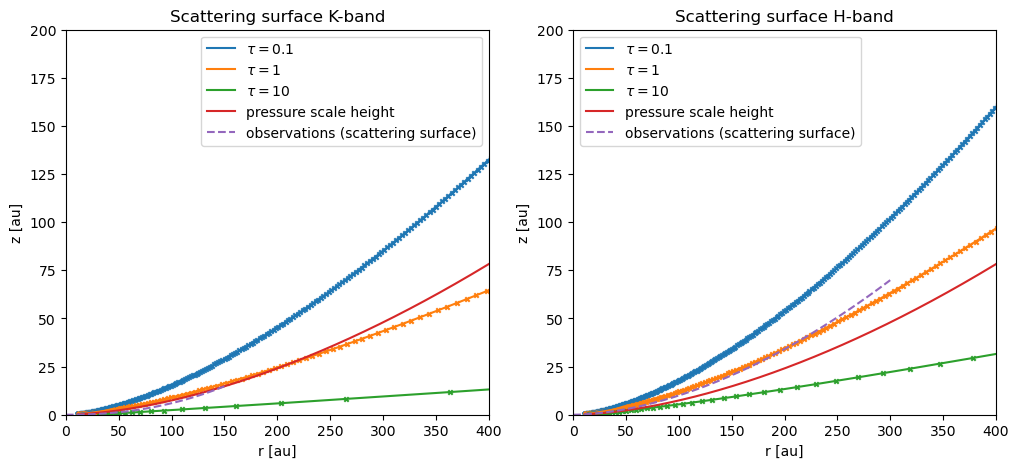

/scratch/2044498/ipykernel_2716118/3827152050.py:91: RuntimeWarning: invalid value encountered in divide
  plt.plot(r_surf/au, dz/dr-z_surf/r_surf, label="from scattering surface")


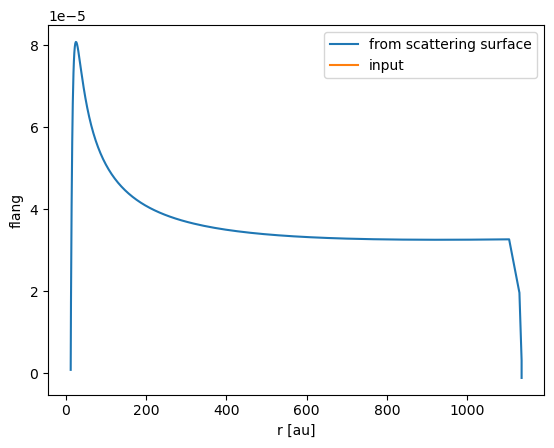

In [75]:
rho_dust_3d, rc, thetac,hp, flang = make_model_no_flang(sigma_0 = 1.7e-1, #g/cm²,
                                               sigma_slope=0,
                                              hp0 = 0.05, # aspect ratio at planet
                                                flaring_index = 0.7,)
flang_like = make_scat(rho_dust_3d, rc, thetac,hp, flang)

## What kind of impossible temperature profile would be required to create these values for the flaring index etc.?

In [103]:
au  = 1.49598e13     # Astronomical Unit       [cm]
pc  = 3.08572e18     # Parsec                  [cm]
ms  = 1.98892e33     # Solar mass              [g]
ts  = 5.78e3         # Solar temperature       [K]
ls  = 3.8525e33      # Solar luminosity        [erg/s]
rs  = 6.96e10        # Solar radius            [cm]
ss  = 5.6703e-5      # Stefan-Boltzmann const  [erg/cm^2/K^4/s]
kk  = 1.3807e-16     # Bolzmann's constant     [erg/K]
mp  = 1.6726e-24     # Mass of proton          [g]
GG  = 6.67408e-08    # Gravitational constant  [cm^3/g/s^2]
pi  = np.pi          # Pi
    


def flaring_to_temp(sigma_0 = 1.7e3, #g/cm²,
                    sigma_slope=0,
                    hp0 = 0.05, # aspect ratio at planet
                    flaring_index = 0.7, flang=0.05):
    
    mstar    = 1.0*ms#2.4*ms
    rstar    = 1.418*rs#2.4*rs
    tstar    = 4400#1e4

    r0       = 57*au    # The radius corresponding to '1' in dimensionless units
    r_res = 1000
    rc = np.power(10,np.linspace(np.log10(0.2), np.log10(20), r_res))*r0
    hp       = rc*hp0*np.power(rc/r0, flaring_index)                      # The pressure scale height
    hpr      = hp/rc                        # The dimensionless hp

    T = hp**2*2.3*mp*GG*mstar/kk/rc**3

    lstar    = 4*pi*rstar**2*ss*tstar**4   # Stellar luminosity
    firr     = flang*lstar/(4*pi*rc**2)     # Irradiative flux
    tmid     = (firr/ss)**0.25  
    
    plt.plot(rc/au, T, label="required temperature")
    plt.plot(rc/au, tmid, label="predicted temperature")
    plt.xlabel("r [au]")
    plt.ylabel("$T_{disk}$ [K]")
    plt.legend()
    plt.title(":(")

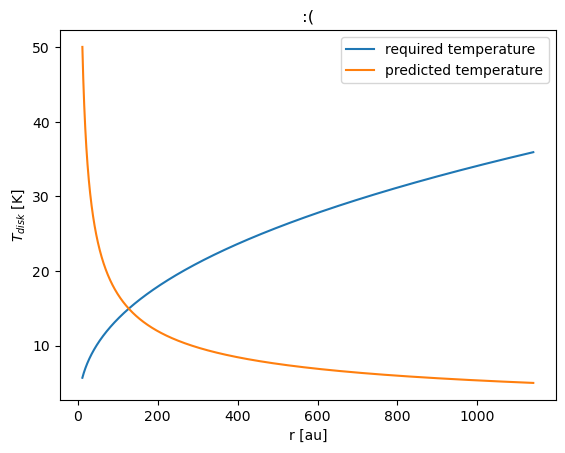

In [104]:
flaring_to_temp()

Conclusion: There is no way to match the observed scattering surfaces with this model for physically possible temperature profiles :(

Either the model is incorrect (implementation error, logical error), or the data is fishy.